In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/shopify_stock.csv")
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       2469 non-null   object 
 1   open       2469 non-null   float64
 2   high       2469 non-null   float64
 3   low        2469 non-null   float64
 4   close      2469 non-null   float64
 5   adj_close  2469 non-null   float64
 6   volume     2469 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 135.2+ KB


In [5]:
df.describe()

,open,high,low,close,adj_close,volume
count,2469.000000,2469.000000,2469.000000,2469.000000,2469.000000,2.469000e+03
mean,48.464345,49.505495,47.347795,48.456613,48.456613,1.657049e+07
std,43.633916,44.470235,42.642546,43.573362,43.573362,1.436909e+07
min,1.939000,1.985000,1.848000,1.933000,1.933000,1.039000e+06
25%,10.479000,10.635000,10.275000,10.450000,10.450000,8.098000e+06
50%,35.640999,36.879002,34.655998,35.874001,35.874001,1.275860e+07
75%,76.080002,77.169998,74.589996,75.800003,75.800003,2.060200e+07
max,171.800003,176.291794,168.509506,169.059998,169.059998,2.089590e+08


In [6]:
df.shape

(2469, 7)

In [7]:
df["date"]=pd.to_datetime(df["date"],utc=True)
df["date"].dtype

datetime64[ns, UTC]

In [8]:
df=df.sort_values("date")

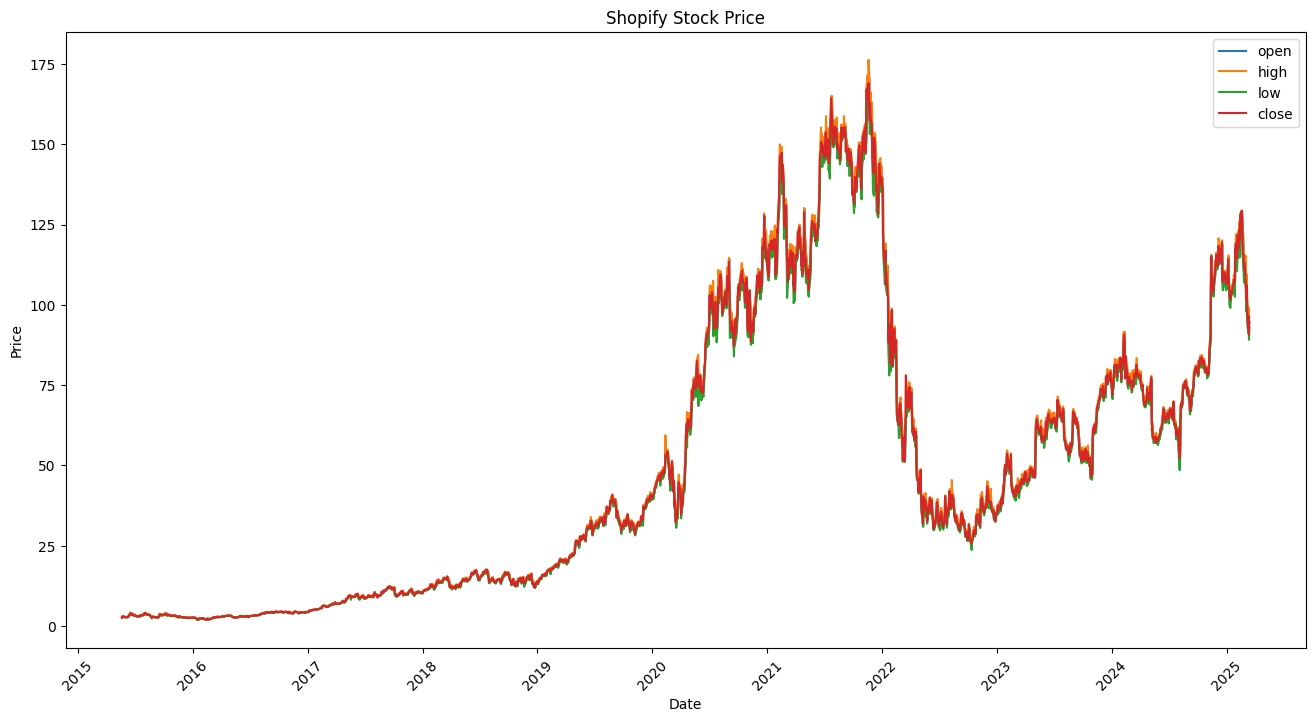

In [9]:
plt.figure(figsize=(16,8))
plt.plot(df.date,df["open"],label="open")
plt.plot(df.date,df["high"],label="high")
plt.plot(df.date,df["low"],label="low")
plt.plot(df.date,df["close"],label="close")

plt.title("Shopify Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Text(0, 0.5, 'Volume')

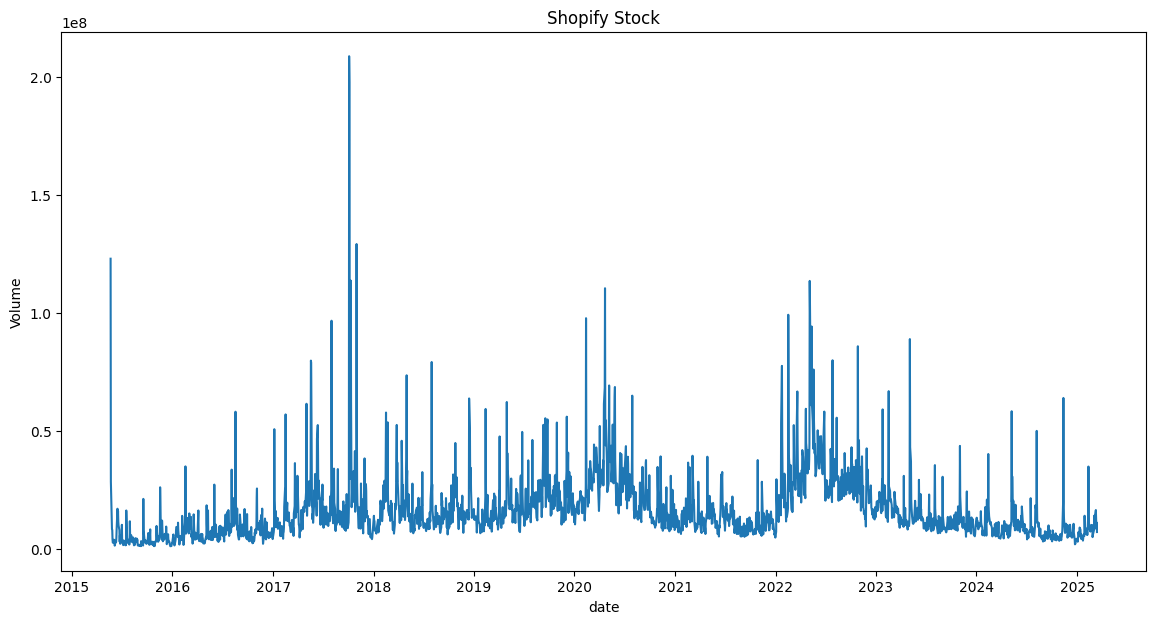

In [10]:
plt.figure(figsize=(14,7))
plt.plot(df.date,df["volume"])
plt.title("Shopify Stock")
plt.xlabel("date")
plt.ylabel("Volume")

In [11]:
df["MA20"]=df["close"].rolling(window=20).mean()
df["MA50"]=df["close"].rolling(window=50).mean()

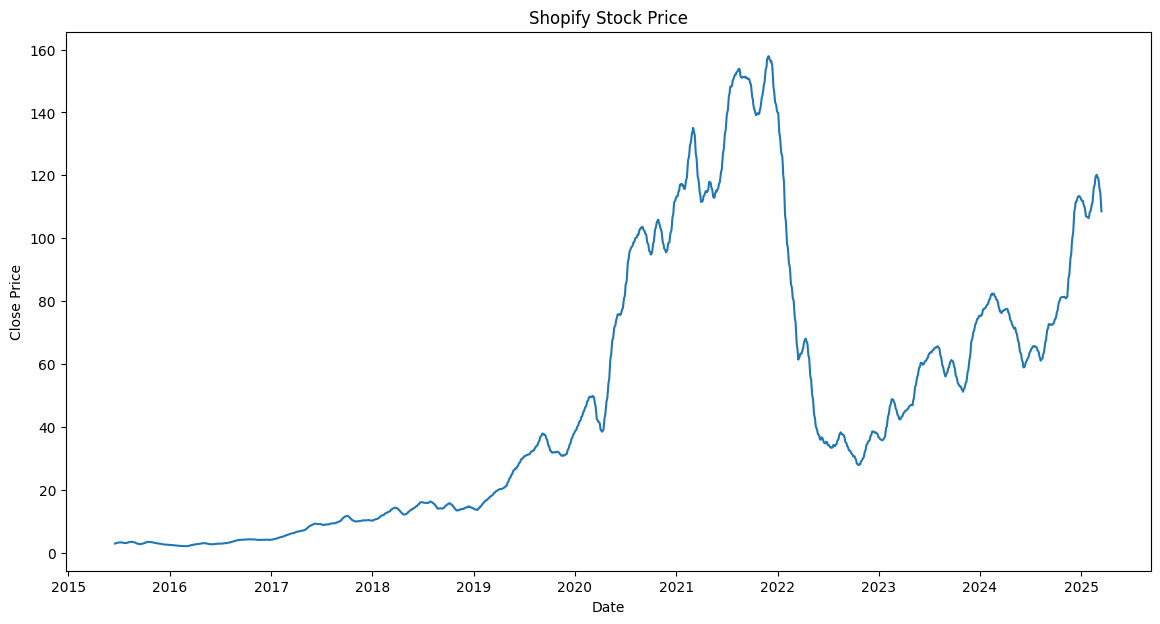

In [28]:
plt.figure(figsize=(14,7))
plt.plot(df.date,df["MA20"])

plt.title("Shopify Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

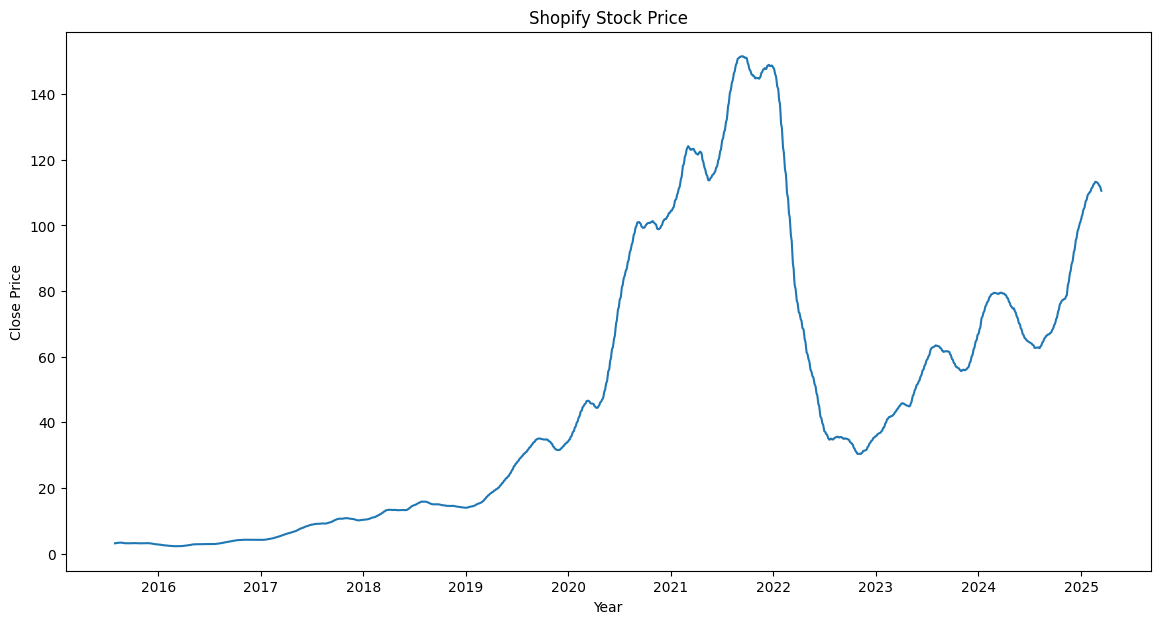

In [29]:
plt.figure(figsize=(14,7))
plt.plot(df.date,df["MA50"])

plt.title("Shopify Stock Price")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.show()

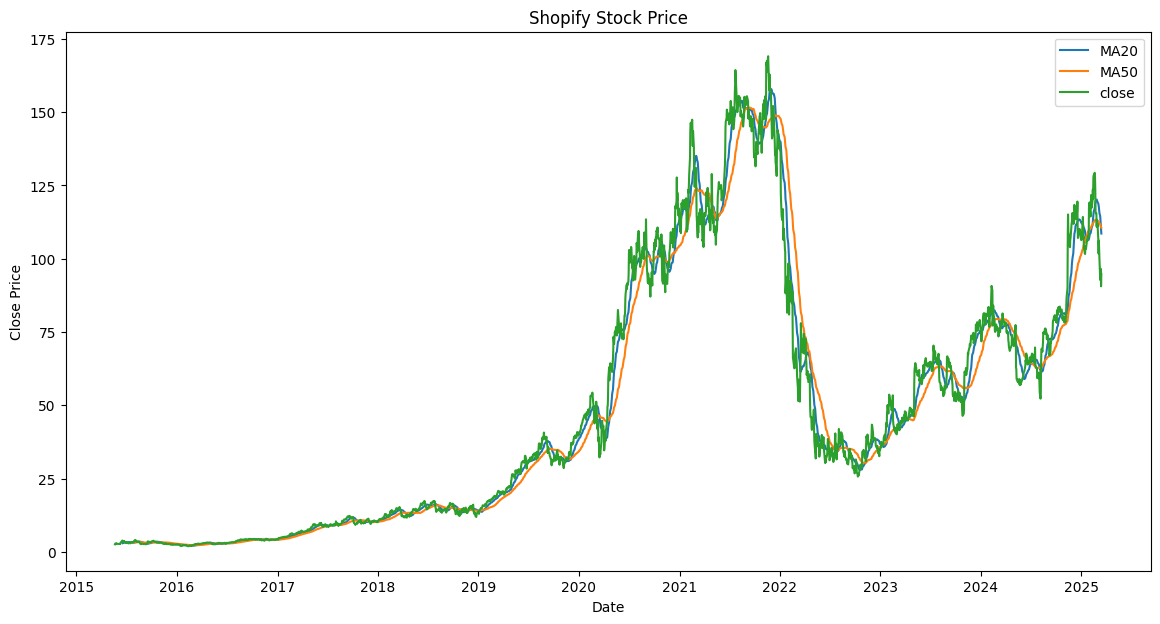

In [26]:
plt.figure(figsize=(14,7))
plt.plot(df.date,df["MA20"],label="MA20")
plt.plot(df.date,df["MA50"],label="MA50")
plt.plot(df.date,df["close"],label="close")

plt.title("Shopify Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [18]:
df["Daily_Return"]=df["close"].pct_change()
df["Daily_Return"].dropna()

,Daily_Return
1,0.102414
2,0.047333
3,-0.072513
4,-0.001818
5,-0.009107
...,...
2464,-0.073704
2465,0.002156
2466,0.038515
2467,-0.061535


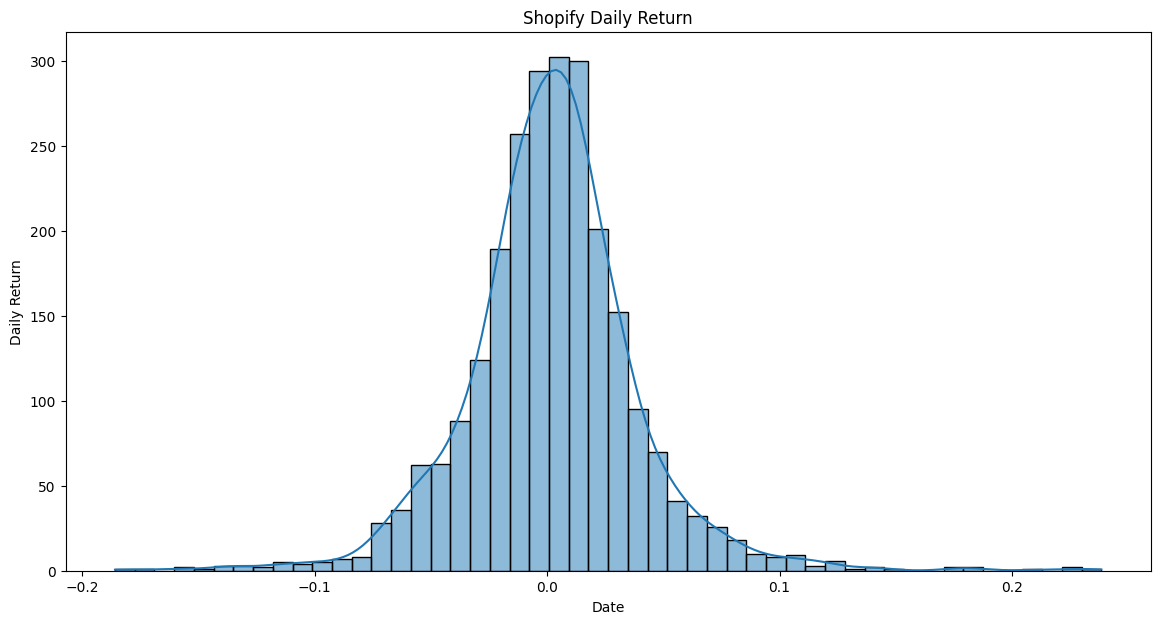

In [20]:
plt.figure(figsize=(14,7))
sns.histplot(
    data=df,
    x="Daily_Return",
    bins=50,
    kde=True,
)
plt.title("Shopify Daily Return")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

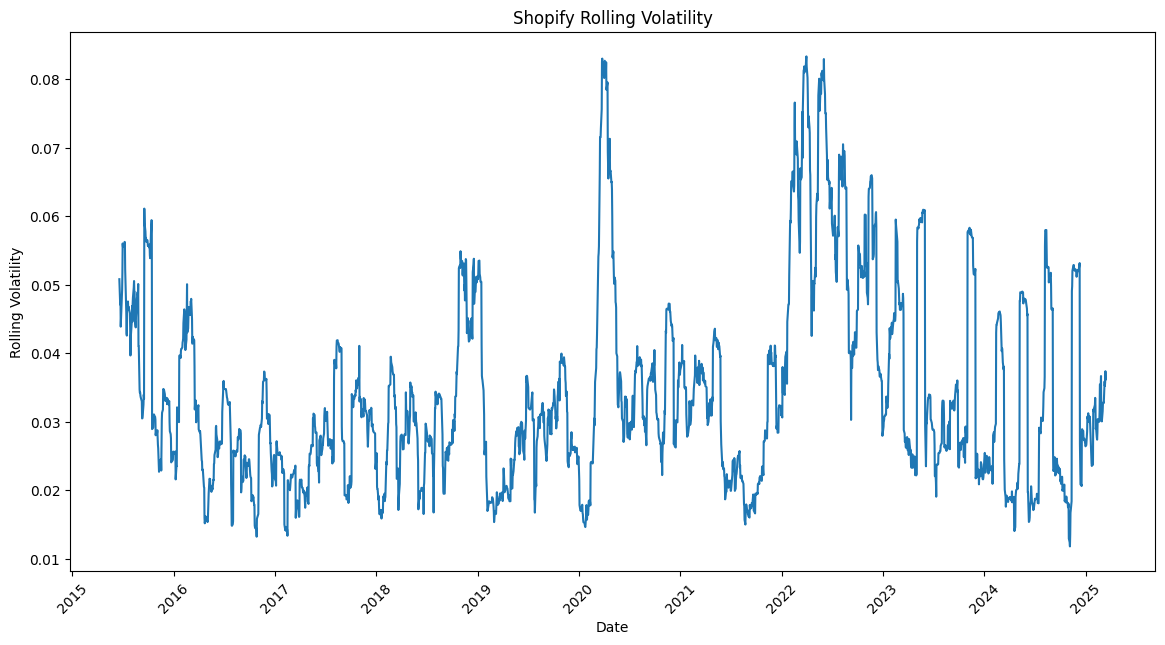

In [31]:
df["Rolling_Volatitlity"]=df["Daily_Return"].std()
plt.figure(figsize=(14,7))
plt.plot(df.date,df["Rolling_Volatility"])
plt.title("Shopify Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.xticks(rotation=45)
plt.show()

In [33]:
df["Rolling_Volatility_20"]=df["Daily_Return"].rolling(window=20).std()
df["Rolling_Volatility_100"]=df["Daily_Return"].rolling(window=100).std()
df["Rolling_Volatility_20"].dropna()
df["Rolling_Volatility_100"].dropna()

,Rolling_Volatility_100
100,0.047811
101,0.046777
102,0.046576
103,0.045957
104,0.046063
...,...
2464,0.035483
2465,0.035481
2466,0.035597
2467,0.036163


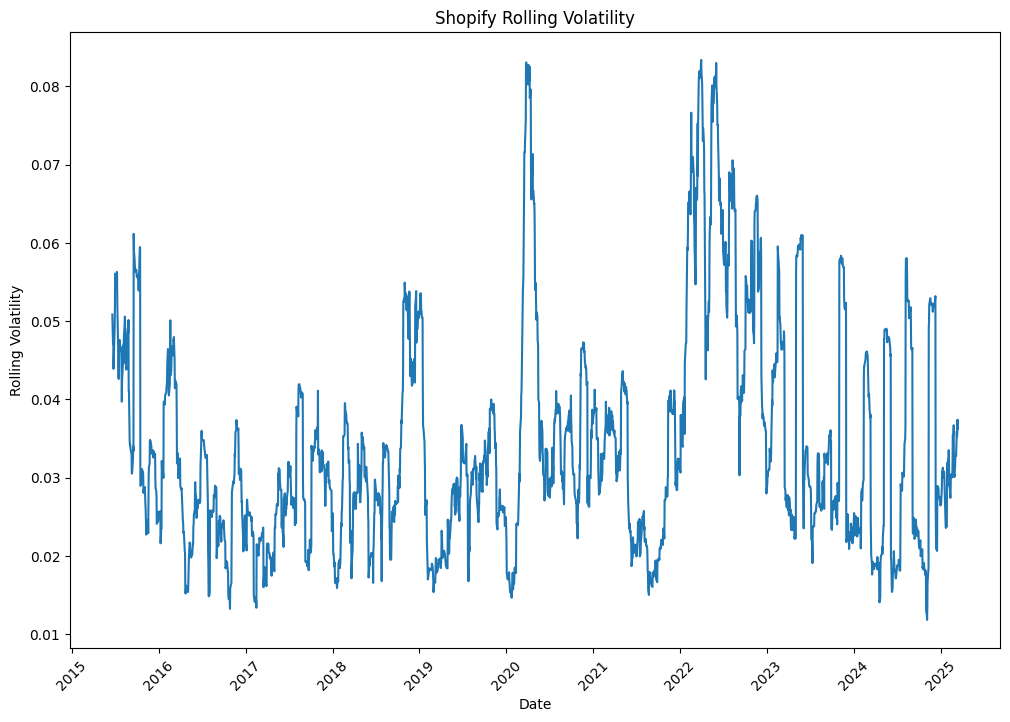

In [32]:
plt.figure(figsize=(12,8))
plt.plot(df.date,df["Rolling_Volatility_20"])
plt.title("Shopify Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.xticks(rotation=45)
plt.show()

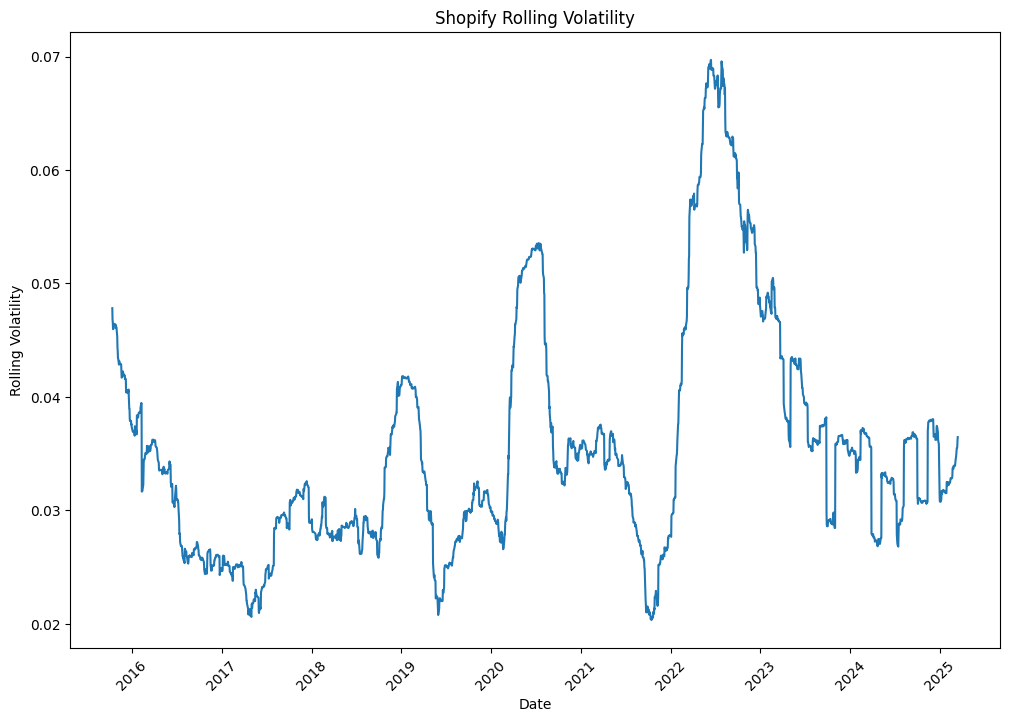

In [34]:
plt.figure(figsize=(12,8))
plt.plot(df.date,df["Rolling_Volatility_100"])
plt.title("Shopify Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.xticks(rotation=45)
plt.show()